# TP2 — WORKING FILE (full solution, single notebook)
## Observations already available on Kabre: maps, time series, vertical section + intro to NCO/CDO

This is the **single working copy** with everything filled in, for you to test and fine-tune on Kabre before deriving a blanked-out student version. Once this runs cleanly end to end, tell me and I'll regenerate the student TP (with `# TODO`s) from this corrected base.

**Fixes applied in this version** (vs. the earlier draft):
- `OBS_DIR` / `SST_FILE` / `WOA_FILE` set to the real paths you gave.
- WOA2009 (`temp_seas.cdf`) is a **seasonal** climatology (4 steps on `T`), not a single annual field — averaged over `T` before plotting.
- WOA dimensions are `X/Y/Z/T`, not `lon/lat/depth/time` — fixed throughout Part A.3.
- No more hardcoded `xlim` guess for WOA longitude — it's now read directly from the file (`ds_woa.X.min()/.max()`).
- `ncwa -a time` used instead of `ncks --mk_rec_dmn` + `ncra` (simpler, faster, doesn't require a record dimension) — see note in B.1.
- All shell calls use `!command {VAR}` (Python brace interpolation), not `%%bash` + `$VAR` or `${VAR}`, which don't interpolate Python variables reliably in this environment.
- `-O` (overwrite) added to every CDO call, and to `ncks`, so re-running cells doesn't fail on existing output files.

## 0. Where is the data?

In [6]:
OBS_DIR = '../../data/DATASETS_PSF/'
#data/DATA/DATASETS_PSF/'

!ls -lh {OBS_DIR}

total 0
drwxr-xr-x@ 30 gcambon  staff   960B Sep 23 21:13 CAMERICA_DS
drwxr-xr-x@ 13 gcambon  staff   416B Sep 23 18:16 GLOBAL_DS


## 1. Quick anatomy check (applying Course 2)

This directly applies what you just saw in Course 2 (netCDF file structure): let's open a real file and locate its dimensions, variables, and attributes.

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

SST_FILE = f"{OBS_DIR}/CAMERICA_DS/sst_central_america_2023.nc"

ds_sst = xr.open_dataset(SST_FILE)
print(ds_sst)

<xarray.Dataset> Size: 2GB
Dimensions:       (time: 365, latitude: 700, longitude: 1200)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * latitude      (latitude) float32 3kB -4.975 -4.925 -4.875 ... 29.92 29.98
  * longitude     (longitude) float32 5kB -120.0 -119.9 -119.9 ... -60.08 -60.03
Data variables:
    analysed_sst  (time, latitude, longitude) float64 2GB ...
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          19811002T000000Z
    time_coverage_start:        19811001T000000Z
    title:                      Global SST & 

---
# Part A — Python / xarray

## A.1 2D horizontal map (mean SST)

/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


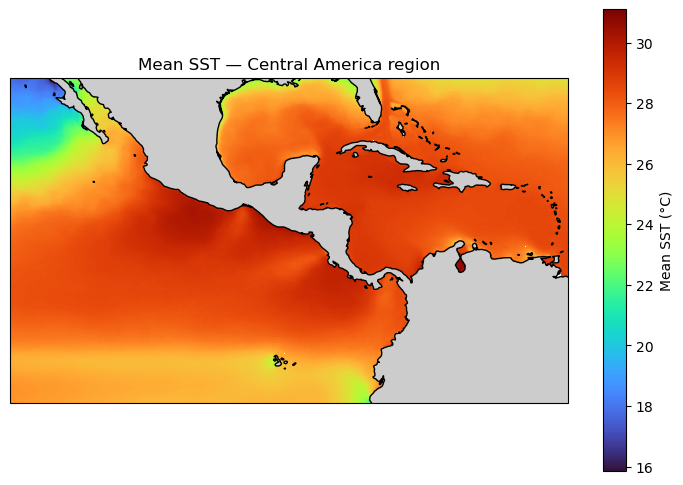

In [8]:
VAR_SST = "analysed_sst"   # adapt if needed

sst_mean = ds_sst[VAR_SST].mean(dim="time")

if float(sst_mean.max()) > 100:
    sst_mean = sst_mean - 273.15

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
sst_mean.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="turbo",
              cbar_kwargs={"label": "Mean SST (°C)"})
ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=2)
ax.add_feature(cfeature.COASTLINE, zorder=3)
ax.set_title("Mean SST — Central America region")
plt.show()

**Expected**: values roughly 24-30°C over the Central America/Caribbean region.

## A.2 Time series at a point

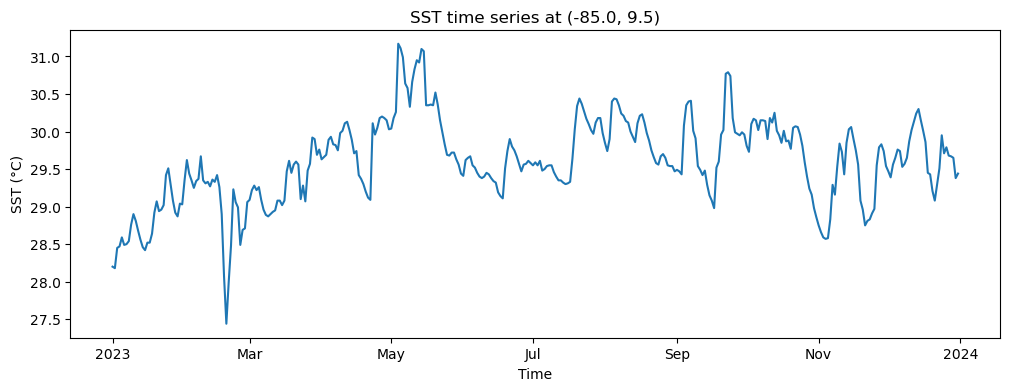

In [9]:
lon0, lat0 = -85.0, 9.5   # off the coast of Costa Rica

ts = ds_sst[VAR_SST].sel(longitude=lon0, latitude=lat0, method="nearest")
if float(ts.max()) > 100:
    ts = ts - 273.15

fig, ax = plt.subplots(figsize=(12, 4))
ts.plot(ax=ax)
ax.set_ylabel("SST (°C)")
ax.set_title(f"SST time series at ({lon0}, {lat0})")
plt.show()

**Expected**: a seasonal cycle, warmer roughly April-May, cooler December-February.

## A.3 Vertical section (WOA2009 seasonal climatology)

`temp_seas.cdf` has dimensions `X, Y, Z, T` (not `lon/lat/depth/time`), and `T` has 4 steps (seasons), not a single annual value — so we average over `T` first.

WOA longitude (X) range: -179.5 to 179.5


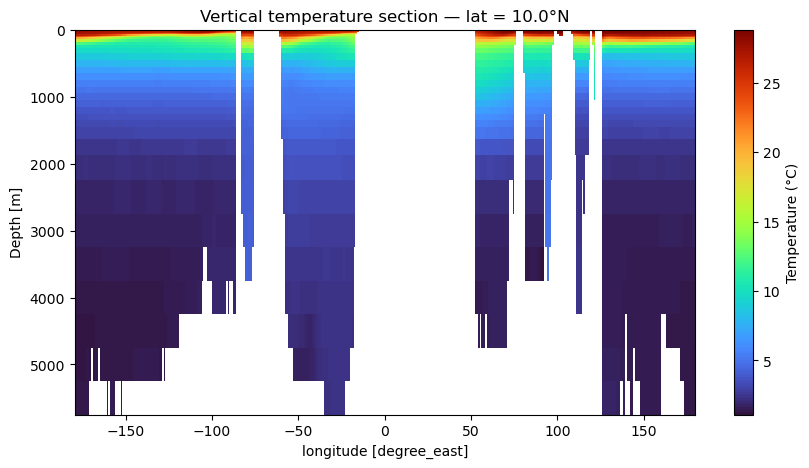

In [10]:
WOA_FILE = f"{OBS_DIR}/GLOBAL_DS/WOA2009/temp_seas.cdf"

ds_woa = xr.open_dataset(WOA_FILE)
VAR_TEMP = "temperature"   # check with ds_woa.data_vars if this changes

print("WOA longitude (X) range:", float(ds_woa.X.min()), "to", float(ds_woa.X.max()))

lat_section = 10.0

temp_section = ds_woa[VAR_TEMP].mean(dim="T", skipna=True).sel(Y=lat_section, method="nearest")

fig, ax = plt.subplots(figsize=(10, 5))
cf = temp_section.plot.pcolormesh(
    x="X", y="Z", ax=ax, cmap="turbo",
    cbar_kwargs={"label": "Temperature (°C)"}
)
ax.invert_yaxis()
ax.set_xlim(float(ds_woa.X.min()), float(ds_woa.X.max()))
ax.set_title(f"Vertical temperature section — lat = {lat_section}°N")
plt.show()

**Expected**: thermocline visible as a tight color transition around 50-150m depth.

### 🚀 Advanced track A

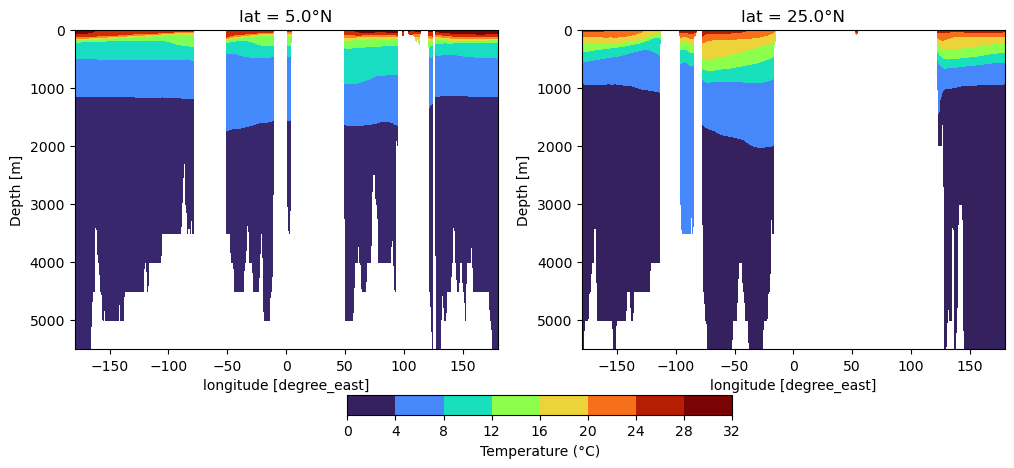

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cf = None
for ax, lat_s in zip(axes, [5.0, 25.0]):
    section = ds_woa[VAR_TEMP].mean(dim="T", skipna=True).sel(Y=lat_s, method="nearest")
    cf = section.plot.contourf(x="X", y="Z", ax=ax, cmap="turbo", add_colorbar=False)
    ax.invert_yaxis()
    ax.set_title(f"lat = {lat_s}°N")
    ax.set_xlim(float(ds_woa.X.min()), float(ds_woa.X.max()))

fig.colorbar(cf, ax=axes, orientation="horizontal", fraction=0.05, pad=0.12, label="Temperature (°C)")
plt.show()

# Discussion: the thermocline is typically shallower near the coast (closer to
# Costa Rica/Panama upwelling zones, ~5°N) than further offshore/north (~25°N),
# because coastal upwelling brings colder, deeper water closer to the surface.

---
# Part B — Command line: NCO and CDO

## B.0 Why the command line?

On an HPC cluster, you often deal with files too large to fully load into memory, or you need to automate processing across hundreds of files (batch scripts, SLURM jobs). NCO and CDO are built for exactly this: fast, scriptable, no need to write Python code.

## B.1 NCO — `ncdump`, `ncks`, `ncwa`

In [12]:
!ncdump -h {SST_FILE}

netcdf sst_central_america_2023 {
dimensions:
	time = 365 ;
	latitude = 700 ;
	longitude = 1200 ;
variables:
	short analysed_sst(time, latitude, longitude) ;
		analysed_sst:_FillValue = -32768s ;
		string analysed_sst:comment = " OSTIA foundation SST" ;
		string analysed_sst:long_name = "analysed sea surface temperature" ;
		string analysed_sst:reference = "C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. Fiedler, W. Wimmer. The operational sea surface temperature and sea ice analysis (OSTIA) system. Remote Sensing Environ., 116 (2012), pp. 140-158 http://dx.doi.org/10.1016/j.rse.2010.10.017" ;
		string analysed_sst:source = "AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P-v04, GOES13-OSISAF-L3C-v2.0, SEVIRI-OSISAF-L3C-v2.0, SLSTRA-C3S-L3C-v2.0, ATSR<1,2>-ESACCI-L3U-v2.0, AATSR-ESACCI-L3U-v2.0, AVHRR<06,07,08,09,10,11,12,14,15,16,17,18,19>-ESACCI-L3U-v2.0, AVHRRMTA-ESACCI-L3U-v2.0, GMI-REMSS-L3U-v2.0, VIIRS-OSPO-L3U-v2.0" ;
		string analysed_sst:standard_name = "sea_su

In [13]:
!ncks -O -d longitude,-90.0,-80.0 -d latitude,5.0,15.0 {SST_FILE} sst_costarica.nc
!ncdump -h sst_costarica.nc | head -20

netcdf sst_costarica {
dimensions:
	time = 365 ;
	latitude = 200 ;
	longitude = 200 ;
variables:
	short analysed_sst(time, latitude, longitude) ;
		analysed_sst:_FillValue = -32768s ;
		string analysed_sst:comment = " OSTIA foundation SST" ;
		string analysed_sst:long_name = "analysed sea surface temperature" ;
		string analysed_sst:reference = "C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. Fiedler, W. Wimmer. The operational sea surface temperature and sea ice analysis (OSTIA) system. Remote Sensing Environ., 116 (2012), pp. 140-158 http://dx.doi.org/10.1016/j.rse.2010.10.017" ;
		string analysed_sst:source = "AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P-v04, GOES13-OSISAF-L3C-v2.0, SEVIRI-OSISAF-L3C-v2.0, SLSTRA-C3S-L3C-v2.0, ATSR<1,2>-ESACCI-L3U-v2.0, AATSR-ESACCI-L3U-v2.0, AVHRR<06,07,08,09,10,11,12,14,15,16,17,18,19>-ESACCI-L3U-v2.0, AVHRRMTA-ESACCI-L3U-v2.0, GMI-REMSS-L3U-v2.0, VIIRS-OSPO-L3U-v2.0" ;
		string analysed_sst:standard_name = "sea_surface_founda

**⚠️ Debug reminder**: if this fails with a *"dimension not found"* error, check the exact dimension names in the `ncdump -h` output above (they might not be `longitude`/`latitude` for a different file).

**On averaging over time**: `ncra` (record average) technically expects `time` to be a *record* dimension, which is why an earlier version of this notebook used `ncks --mk_rec_dmn` first to convert it — but that rewrites the whole file and can be slow. `ncwa -a DIM` (weighted average) averages over **any** dimension directly, record or not — simpler and faster for our case.

In [14]:
!ncwa -O -a time sst_costarica.nc sst_costarica_mean_nco.nc
!ncdump -v analysed_sst sst_costarica_mean_nco.nc | tail -20

    _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, 
    _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, 
    _, _, _, _, _, _, _, _, _, _, _, _, _, _, 302.098678180938, 
    302.153198727664, 302.191801466527, 302.223034342542, 302.233335712174, 
    302.235527492947, 302.230185027313, 302.216404205704, 302.200459000581, 
    302.180075439392, 302.160212426138, 302.140322015623, 302.12517133103, 
    302.112212427211, 302.103801468494, 302.096787770021, 302.09040420852, 
    302.080404208743, 302.069061743243, 302.053226127159, 302.036897360401, 
    302.019828867632, 302.003993251547, 301.988979553253, 301.97544530698, 
    301.96328092369, 301.952979554057, 301.94711654049, 301.943445307695, 
    301.946650787075, 301.95193845819, 301.959089142962, 301.963883663403, 
    301.966869964706, 301.963637088066, 301.956952156708, 301.947253526788, 
    301.936294622923, 301.925856266992, 301.918212431547, 301.913582294664, 
    301.911582294

## B.2 CDO — `sinfo`, `timmean`, `sellonlatbox`

In [15]:
!cdo sinfo {SST_FILE}

cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lon<
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lat<
   File format : NetCDF4
    -1 : Institut Source   T Steptype Levels Num    Points Num Dtype : Parameter ID
     1 : unknown  AMSR2-REMSS-L2P-v2 v instant       1   1    840000   1  I16  : -1            
   Grid coordinates :
     1 : lonlat                   : points=840000 (1200x700)
                        longitude : -119.975 to -60.025 by 0.05 degrees_east
                         latitude : -4.975 to 29.975 by 0.05 degrees_north
   Vertical coordinates :
     1 : surface                  : levels=1
   Time coordinate :
                             time : 365 steps
     RefTime =  1981-01-01 00:00:00  Units = seconds  Calendar = proleptic_gregorian
  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss
  2023-01-01 00:00:00  2023-01-02 00:00:00  2023-01-03 00:00:00  2023-01-04 00:00:00
  2023-01-05 00:00:00

In [16]:
!cdo -O sellonlatbox,-90.0,-80.0,5.0,15.0 {SST_FILE} sst_costarica_cdo.nc
!cdo -O timmean sst_costarica_cdo.nc sst_costarica_mean_cdo.nc
!cdo sinfo sst_costarica_mean_cdo.nc

cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lon<
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lat<
cdo    sellonlatbox: Processed 306600000 values from 1 variable over 365 timesteps [0.55s 79MB]
cdo    timmean:                        1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 8 8 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9 910cdo    timmean: Processed 14600000 values from 1 variable over 365 timesteps [0.05s 40MB]
   File format : NetCDF4
    -1 : Institut Source   T Steptype Levels Num    Points Num Dtype : Parameter ID
     1 : unknown  AMSR2-REMSS-L2P-v2 v instant       1   1     40000   1  F32  : -1            
   Grid coordinates :
     1 : lonlat                   : points=40000 (200x200)
                        longitude : -89.975 to -80.025 by 0.04999998 degrees_east
                         latitude : 5.025 to 14.975 by 0.05 degrees_north
   Ver

### 🚀 Advanced track B — chaining CDO operators

In [17]:
# Chained: anomaly = file - monthly climatology of file, in one command
!cdo -O ymonsub {SST_FILE} -ymonmean {SST_FILE} sst_anomaly.nc
!cdo sinfo sst_anomaly.nc

cdo(1) ymonmean: Process started
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lon<
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lat<
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lon<
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lat<
cdo    ymonsub: Processed 316680000 values from 2 variables over 377 timesteps [1.87s 441MB]
   File format : NetCDF4
    -1 : Institut Source   T Steptype Levels Num    Points Num Dtype : Parameter ID
     1 : unknown  AMSR2-REMSS-L2P-v2 v instant       1   1    840000   1  F32  : -1            
   Grid coordinates :
     1 : lonlat                   : points=840000 (1200x700)
                        longitude : -119.975 to -60.025 by 0.05 degrees_east
                         latitude : -4.975 to 29.975 by 0.05 degrees_north
   Vertical coordinates :
     1 : surface                  : levels=1
   Time coordinate :
                             time : 365 steps
    

## B.3 Cross-check (critical thinking!)

In [18]:
ds_check_cdo = xr.open_dataset("sst_costarica_mean_cdo.nc")
val_cdo = float(ds_check_cdo[VAR_SST].mean())
if val_cdo > 100:
    val_cdo -= 273.15

ds_check_nco = xr.open_dataset("sst_costarica_mean_nco.nc")
val_nco = float(ds_check_nco[VAR_SST].mean())
if val_nco > 100:
    val_nco -= 273.15

sst_costarica_xr = ds_sst[VAR_SST].sel(longitude=slice(-90, -80), latitude=slice(5, 15))
val_xr = float(sst_costarica_xr.mean())
if val_xr > 100:
    val_xr -= 273.15

for name, v in [("Python/xarray", val_xr), ("NCO", val_nco), ("CDO", val_cdo)]:
    print(f"{name:15s} : {v:.3f}")

# Note: if latitude is stored decreasing (90 -> -90) rather than increasing,
# slice(5, 15) silently returns an empty selection. Check ds_sst.latitude.values
# ordering if val_xr comes out as NaN, and use slice(15, 5) instead in that case.

Python/xarray   : 29.044
NCO             : 29.044
CDO             : 29.044


**Expected**: the 3 values should match to within ~0.01°C.

---
## C. NCO/CDO vs Python: when to use what?

| Criterion | NCO / CDO | Python (xarray) |
|---|---|---|
| Batch processing across many files / SLURM scripts | ✅ Very well suited | Possible but more verbose |
| Large files (avoid loading everything into RAM) | ✅ Optimized | Needs dask to stay efficient |
| Visualization, maps, figures | ❌ Not designed for this | ✅ Very rich (matplotlib, cartopy) |
| Advanced statistics, machine learning | ❌ | ✅ |
| Learning curve | Quick for simple operations | Longer at first |
| Reproducibility / sharing (notebook) | Limited | ✅ Self-documenting notebook |

**In practice**: many people use CDO/NCO for quick upstream preprocessing (extraction, averaging, regridding), then Python for detailed analysis and figures.

---
## D. Debugging exercise — solution

`ds_sst.data_vars` reveals the actual variable name is `analysed_sst`, not `sea_surface_temperature`.

In [19]:
ds_sst.data_vars

Data variables:
    analysed_sst  (time, latitude, longitude) float64 2GB 297.9 297.9 ... 295.8

In [20]:
variable_temperature = ds_sst["analysed_sst"].mean("time")
print(variable_temperature)

<xarray.DataArray 'analysed_sst' (latitude: 700, longitude: 1200)> Size: 7MB
array([[299.99643165, 299.99237686, 299.9879111 , ...,          nan,
                 nan,          nan],
       [300.0029248 , 299.99908919, 299.99451384, ...,          nan,
                 nan,          nan],
       [300.00782891, 300.00476042, 300.00081521, ...,          nan,
                 nan,          nan],
       ...,
       [290.92424007, 290.90780172, 290.89887021, ..., 297.91629471,
        297.90722622, 297.90333581],
       [290.88950035, 290.87330857, 290.86284282, ..., 297.87371937,
        297.86495225, 297.86133581],
       [290.84980172, 290.83308939, 290.82240446, ..., 297.83566458,
        297.82673307, 297.82267828]], shape=(700, 1200))
Coordinates:
  * latitude   (latitude) float32 3kB -4.975 -4.925 -4.875 ... 29.88 29.92 29.98
  * longitude  (longitude) float32 5kB -120.0 -119.9 -119.9 ... -60.08 -60.03
Attributes:
    comment:         OSTIA foundation SST
    long_name:      analysed 

---
## E. Pair mini-synthesis — instructor notes

There's no single "correct" output since students pick their own variable/region. When circulating, check that each pair has:
- A 2D map with a sensible colorbar range for the chosen variable.
- A time series showing a plausible seasonal or spatial pattern (not flat/constant, not absurd units).
- Two independently computed means that agree — if not, that's the debugging opportunity to use, not a failure to fix for them immediately.

### 🚀 For those who finish early
The CDO chaining challenge above, or a full monthly climatology (`cdo ymonmean`) plotted as 12 subplots (see `sst_central_america.ipynb` in `notebooks/ocean/`).

## To go further

- CDO documentation: https://code.mpimet.mpg.de/projects/cdo
- NCO documentation: http://nco.sourceforge.net/nco.html
- xarray documentation: https://docs.xarray.dev